<a href="https://colab.research.google.com/github/San0160/Image-segmentaion/blob/main/Image_segmentaion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
# Importing relevant modules.

import random
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO  # API for COCO dataset.
import skimage.io as io

%matplotlib inline

In [58]:
# Import and mount Google Drive.

from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
# Unzip the dataset file and store it in a folder called images.

!unzip "/content/drive/MyDrive/RMDS_segmentation_dataset_ADE20K_350.zip" -d "/content/drive/MyDrive/ADE20K/"

Archive:  /content/drive/MyDrive/RMDS_segmentation_dataset_ADE20K_350.zip
replace /content/drive/MyDrive/ADE20K/instances_train.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [60]:
# Define location of training data (images and labels).

train_data_path = "/content/drive/MyDrive/ADE20K/train"
train_annotation_file = "/content/drive/MyDrive/ADE20K/instances_train.json"

In [61]:
# Initialising COCO API for instance annotations.

coco = COCO(train_annotation_file)

loading annotations into memory...
Done (t=0.05s)
creating index...
index created!


In [62]:
# Extract and display COCO categories and supercategories for the training dataset.

category_IDs = coco.getCatIds()
categories = coco.loadCats(category_IDs)

print(categories)

names_cats = [cats["name"] for cats in categories]
print(len(names_cats), "COCO categories:", " ".join(names_cats))

[{'id': 1, 'name': 'bed'}, {'id': 2, 'name': 'windowpane'}, {'id': 3, 'name': 'cabinet'}, {'id': 4, 'name': 'person'}, {'id': 5, 'name': 'door'}, {'id': 6, 'name': 'table'}, {'id': 7, 'name': 'curtain'}, {'id': 8, 'name': 'chair'}, {'id': 9, 'name': 'car'}, {'id': 10, 'name': 'painting'}, {'id': 11, 'name': 'sofa'}, {'id': 12, 'name': 'shelf'}, {'id': 13, 'name': 'mirror'}, {'id': 14, 'name': 'armchair'}, {'id': 15, 'name': 'seat'}, {'id': 16, 'name': 'fence'}, {'id': 17, 'name': 'desk'}, {'id': 18, 'name': 'wardrobe'}, {'id': 19, 'name': 'lamp'}, {'id': 20, 'name': 'bathtub'}, {'id': 21, 'name': 'railing'}, {'id': 22, 'name': 'cushion'}, {'id': 23, 'name': 'box'}, {'id': 24, 'name': 'column'}, {'id': 25, 'name': 'signboard'}, {'id': 26, 'name': 'chest of drawers'}, {'id': 27, 'name': 'counter'}, {'id': 28, 'name': 'sink'}, {'id': 29, 'name': 'fireplace'}, {'id': 30, 'name': 'refrigerator'}, {'id': 31, 'name': 'stairs'}, {'id': 32, 'name': 'case'}, {'id': 33, 'name': 'pool table'}, {'i

In [63]:
# Define function to extract category name from ID.

def get_category_name(class_ID, categories):
    for i in range(len(categories)):
        if categories[i]["id"] == class_ID:
            return categories[i]["name"]
    return "None"

In [64]:
# Look at one example.

category_name_10 = get_category_name(10, categories)
print(f"The category name is {category_name_10}.")

# Make sure to check out some others.

The category name is painting.


In [65]:
# Get all training images containing a given object category or categories.
# Remember, for this assignment we will focus on the classes "person", "car", "book", "airplane"!

filter_class = ["airplane", "car", "book", "person"]
category_IDs = coco.getCatIds(catNms=filter_class)

# Collect image IDs for each category and then combine them to get unique IDs
all_image_ids = set()
for cat_id in category_IDs:
    img_ids_for_cat = coco.getImgIds(catIds=[cat_id])
    all_image_ids.update(img_ids_for_cat)

image_IDs = list(all_image_ids)

print(f"Number of images containing specified category(ies): {len(image_IDs)}.")
print(f"IDs of images containing specified category(ies): {image_IDs}.")

# What happens when you are filtering for a different category or multiple classes?

Number of images containing specified category(ies): 350.
IDs of images containing specified category(ies): [20500, 20502, 20513, 20515, 20540, 20554, 20556, 20575, 20579, 20585, 20589, 20590, 20591, 20596, 20600, 20614, 20616, 20618, 20624, 20626, 20630, 20633, 20642, 20647, 20649, 20651, 20690, 20699, 20702, 20705, 20709, 20711, 20712, 20720, 20728, 20729, 20730, 20737, 20741, 20748, 20766, 20772, 20773, 20781, 20782, 20785, 20789, 20792, 20793, 20799, 20809, 20816, 20818, 20819, 20820, 20824, 20828, 20829, 20830, 20832, 20836, 20842, 20847, 20854, 20855, 20857, 20859, 20860, 20865, 20874, 20881, 20887, 20890, 20903, 20909, 20924, 20925, 20934, 20937, 20943, 20944, 20945, 20952, 20953, 20957, 20958, 20962, 20977, 20988, 20994, 20995, 20996, 20997, 20998, 21000, 21002, 21005, 21007, 21010, 21014, 21015, 21017, 21018, 21022, 21023, 21026, 21027, 21028, 21032, 21036, 21037, 21039, 21040, 21042, 21044, 21045, 21046, 21050, 21051, 21056, 21057, 21061, 21065, 21066, 21067, 21071, 21072, 21

{'file_name': 'ADE_val_00001864.jpg', 'width': 256, 'id': 22073, 'height': 256}


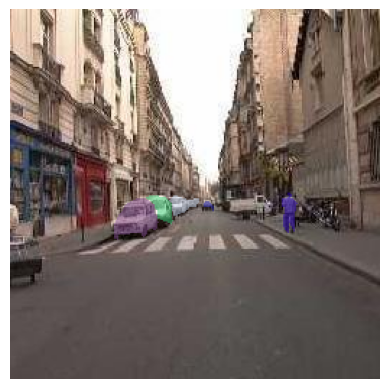

In [66]:
# Load and display example training image with segmentation masks.

training_image = unique_training_images[50]
print(training_image)

image = io.imread(f'{train_data_path}/{training_image["file_name"]}')
plt.axis("off")
plt.imshow(image)

training_image_annotations_ID = coco.getAnnIds(
    imgIds=training_image["id"], catIds=target_classes_IDs, iscrowd=None
)
training_image_annotations = coco.loadAnns(training_image_annotations_ID)
coco.showAnns(training_image_annotations, draw_bbox=False)

plt.show()

In [67]:
# To generate segmentation mask use annToMask function and extract the info stored in the annotations.
# For example, for the first object in our example training image:

mask_example = coco.annToMask(training_image_annotations[0])

print(type(mask_example))
print(mask_example)
print(mask_example.shape)
print(np.max(mask_example))
print(np.min(mask_example))

<class 'numpy.ndarray'>
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
(256, 256)
1
0


Unique pixel values in the mask: [2. 4. 5.]


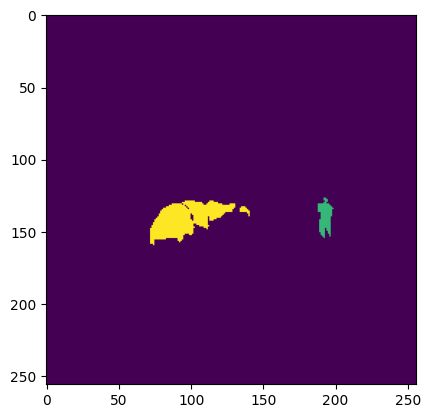

In [68]:
# Plotting the segmentation masks with different colours.
# There are many ways to do this. This is just one example.

mask = np.zeros((training_image["height"], training_image["width"]))

for i in range(len(training_image_annotations)):
    # Get object category name.
    object_category = get_category_name(
        training_image_annotations[i]["category_id"], categories
    )
    # Assign pixel value based on location in target_classes list.
    pixel_value = target_classes.index(object_category) + 1
    # Assign pixel value to mask based on annToMask output.
    mask = np.maximum(coco.annToMask(training_image_annotations[i]) * 3 + pixel_value, mask)

print(f"Unique pixel values in the mask: {np.unique(mask)}")

plt.imshow(mask)
plt.show()